### Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Hipotesis



- A mayor edad del futbolista (player_age), mayor es la cantidad de días (Days) necesarios para recuperarse de una misma lesión.

- Las lesiones son cada vez más graves/frecuentes con el paso de las temporadas (debido al cansancio acumulado y la seguidilla de partidos)


### Datos

##### ETL

In [ ]:
df = pd.read_csv('futbol.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 15603 filas, 11 columnas


In [ ]:
df.head()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15603 entries, 0 to 15602
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Season               15603 non-null  object
 1   Injury               15603 non-null  object
 2   Days                 15603 non-null  object
 3   Games missed         15603 non-null  int64 
 4   injury_from_parsed   15603 non-null  object
 5   injury_until_parsed  15603 non-null  object
 6   player_name          15603 non-null  object
 7   player_age           15603 non-null  int64 
 8   player_position      15603 non-null  object
 9   club                 15603 non-null  object
 10  league               15603 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


In [ ]:
total_nulos = df.isnull().sum().sum()
print(f"Cantidad total de valores nulos: {total_nulos}")

Cantidad total de valores nulos: 0


In [ ]:
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {cantidad_duplicados}")

Cantidad de registros duplicados: 0


In [ ]:
#Valores únicos por columna
df.nunique()

,0
Season,5
Injury,276
Days,374
Games missed,77
injury_from_parsed,1729
injury_until_parsed,1737
player_name,4081
player_age,28
player_position,14
club,145


In [ ]:
# Distribucion de las edades
df["player_age"].describe()

,player_age
count,15603.000000
mean,26.550663
std,4.398164
min,16.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,43.000000


##### Grafico 10 lesiones mas frecuentes

Top 10 lesiones más frecuentes:
Injury
Hamstring injury     1256
Corona virus          986
Muscle injury         960
muscular problems     940
Knee injury           584
Ill                   578
Ankle injury          572
Knock                 441
Calf injury           430
Fitness               427
Name: count, dtype: int64


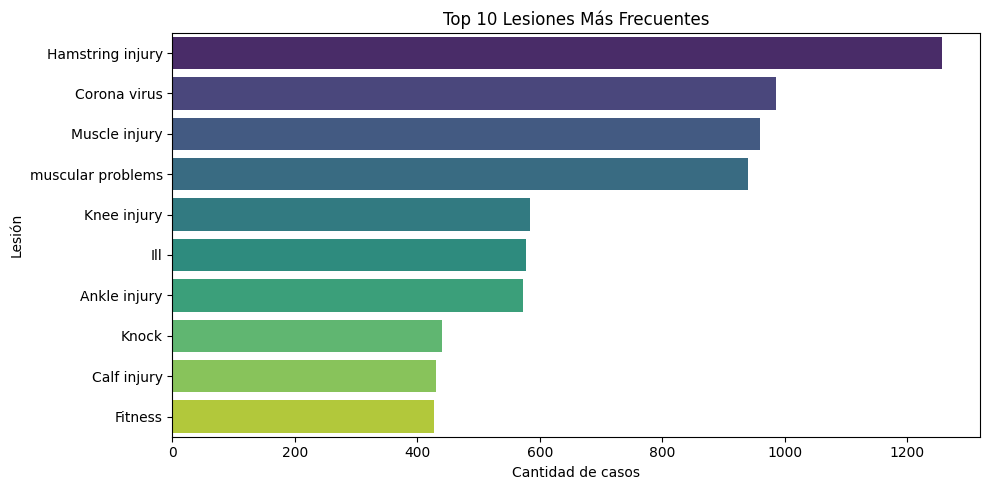

In [ ]:
top_10_lesiones = df["Injury"].value_counts().head(10)
print("Top 10 lesiones más frecuentes:")
print(top_10_lesiones)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_10_lesiones.values,
    y=top_10_lesiones.index,
    hue=top_10_lesiones.index,
    palette="viridis",
    legend=False,
)
plt.title("Top 10 Lesiones Más Frecuentes")
plt.xlabel("Cantidad de casos")
plt.ylabel("Lesión")
plt.tight_layout()
plt.show()

In [ ]:
#traduccion_lesiones = {
    "Hamstring injury": "Lesión en los isquiotibiales",
    "Corona virus": "Coronavirus",
    "Muscle injury": "Lesión muscular",
    "muscular problems": "Problemas musculares",
    "Knee injury": "Lesión de rodilla",
    "Ill": "Enfermedad",
    "Ankle injury": "Lesión de tobillo",
    "Knock": "Golpe / Contusión",
    "Calf injury": "Lesión en la pantorrilla",
    "Fitness": "Falta de ritmo físico",
}

##### Grafico Edad vs Lesion

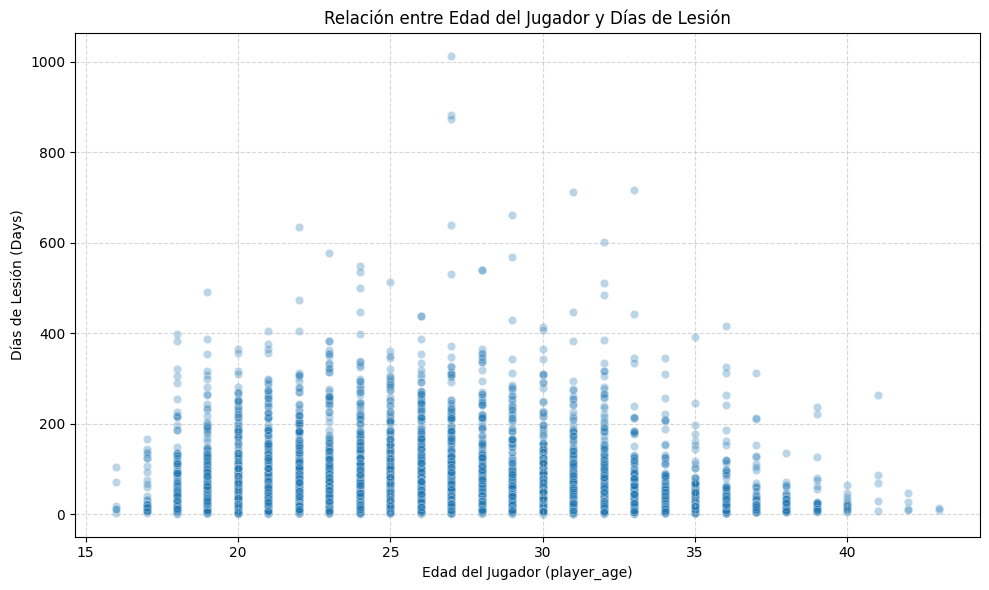

In [ ]:
#Limpiar la columna 'Days' extrayendo el número y convirtiendo a int
df["Days_num"] = df["Days"].str.extract(r"(\d+)").astype(int)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="player_age",
    y="Days_num",
    alpha=0.3,
    color="#1f77b4",
)

plt.title("Relación entre Edad del Jugador y Días de Lesión")
plt.xlabel("Edad del Jugador (player_age)")
plt.ylabel("Días de Lesión (Days)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#Dias de lesión mayores a 800
casos_extremos = df[df["Days_num"] > 800][
    [
        "player_name",
        "player_age",
        "club",
        "league",
        "Injury",
        "Days",
        "Games missed",
        "Season",
    ]
]

casos_extremos

#Knee injury - Lesión de rodilla
#Knee surgery - Cirugía de rodilla

,player_name,player_age,club,league,Injury,Days,Games missed,Season
4784,Jack O'Connell,27,Sheffield United,Premier League,Knee injury,1013 days,145,20/21
5477,Kortney Hause,27,Aston Villa,Premier League,Knee surgery,883 days,131,22/23
7896,Martín Merquelanz,27,Rayo Vallecano,La Liga,Knee injury,874 days,126,21/22


* **Jack O'Connell (Sheffield United)**: Sufrió una grave lesión en el cartílago de la rodilla en septiembre de 2020. Tuvo múltiples cirugías y complicaciones durante su proceso de rehabilitación que le impidieron volver a jugar un partido oficial, hasta que finalmente anunció su retiro profesional prematuro.

* **Martín Merquelanz (Rayo Vallecano / Real Sociedad)**: En septiembre de 2021, durante un partido frente al Levante, sufrió una severa lesión del cartílago articular de la rodilla izquierda. Atravesó un calvario de casi dos años y medio de operaciones y recuperación hasta poder reincorporarse a los entrenamientos.

* **Kortney Hause (Aston Villa / Watford)**: Tuvo que someterse a una cirugía de rodilla a finales de 2022 mientras estaba a préstamo. La recuperación se complicó prolongadamente dejándolo fuera de competencia durante más de dos años sin poder disputar minutos oficiales con el primer equipo.

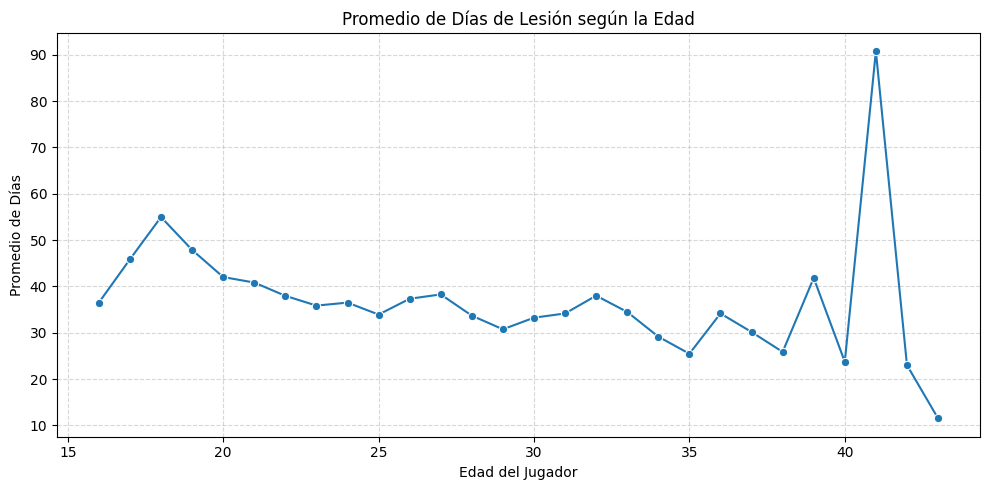

In [ ]:
# Promedio de días de recuperación según cada edad
dias_por_edad = df.groupby("player_age")["Days_num"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=dias_por_edad, x="player_age", y="Days_num", marker="o")
plt.title("Promedio de Días de Lesión según la Edad")
plt.xlabel("Edad del Jugador")
plt.ylabel("Promedio de Días")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

##### Apuntes

Por hacer

Verificar formato fechas,

Lesiones mas frecuentes,

Dias de recuperacion por lesion,

Lesiones por posicion,

Lo mismo, pero por cada liga,

Deteccion de outliers,

Armar repositorio GitHub

Posible variable a predecir


"Games missed" - cuántos partidos se perderá un futbolista debido a una lesión?,

"Days" - cuántos días estará lesionado un jugador?